Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [5]:
# loading the csv data to a Pandas DataFrame
gold_data = pd.read_csv('gld_price_data.csv')

In [7]:
# print first 5 rows in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [9]:
# print last 5 rows of the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [11]:
# number of rows and columns
gold_data.shape

(2290, 6)

In [13]:
# getting some basic informations about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [15]:
# checking the number of missing values
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [17]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1. Positive Correlation
2. Negative Correlation

In [22]:
correlation = gold_data.drop(['Date'], axis=1).corr()

<Axes: >

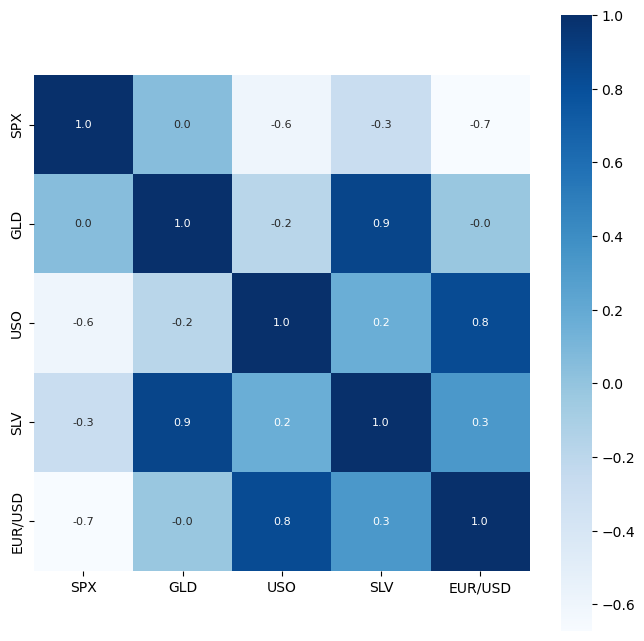

In [24]:
# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [26]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<Axes: xlabel='GLD', ylabel='Count'>

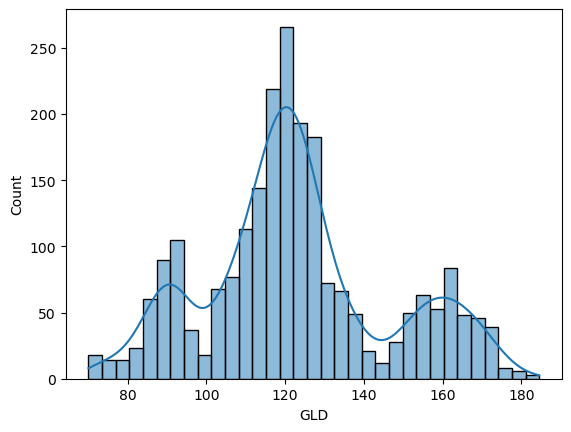

In [107]:
# checking the distribution of the GLD Price
sns.histplot(gold_data['GLD'], kde=True)

Splitting the Features and Target

In [31]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [33]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [35]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training data and Test Data

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model Training:
Random Forest Regressor

In [41]:
regressor = RandomForestRegressor(n_estimators=100)

In [43]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [46]:
# prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [48]:
print(test_data_prediction)

[168.49989887  81.94680001 116.18269982 127.60250088 120.79770092
 154.70599742 150.39459846 125.91000038 117.34399865 126.03740038
 116.49090082 171.91120053 141.60359836 167.55609832 115.27669998
 117.85380036 138.28030256 170.04760124 159.51450221 156.68179994
 155.27600045 125.15620025 175.35929892 157.16120287 125.25590035
  93.85580004  77.5096002  120.39630008 119.1149995  167.38869998
  88.18879999 125.4188001   91.33570098 117.69230006 120.98659966
 136.42930075 115.93620104 115.04240056 148.07300006 107.34540135
 104.78320248  87.12379782 126.41000049 117.86799952 154.28439883
 119.61629996 108.2747003  107.86639824  93.20920067 127.05579807
  75.06850022 113.62119922 121.34269998 111.24309923 118.85709902
 120.64729925 159.09129999 168.60320147 146.94449675  85.74749894
  94.28650037  86.8943985   90.46520025 119.08260034 126.41360067
 127.54050019 170.87970069 122.20469916 117.32859913  98.54849991
 168.35470099 143.38289907 132.12270262 121.27890188 120.82509952
 119.50050

In [83]:
# Random Forest predictions
rf_pred = regressor.predict(X_test)

print("\nRandom Forest Performance")

print("R2 Score:", r2_score(Y_test, test_data_prediction))
print("MAE:", mean_absolute_error(Y_test, test_data_prediction))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_data_prediction)))


Random Forest Performance
R2 Score: 0.9891518715339833
MAE: 1.3323811498034912
RMSE: 2.3920231716385607


Compare the Actual Values and Predicted Values in a Plot

In [53]:
Y_test = list(Y_test)

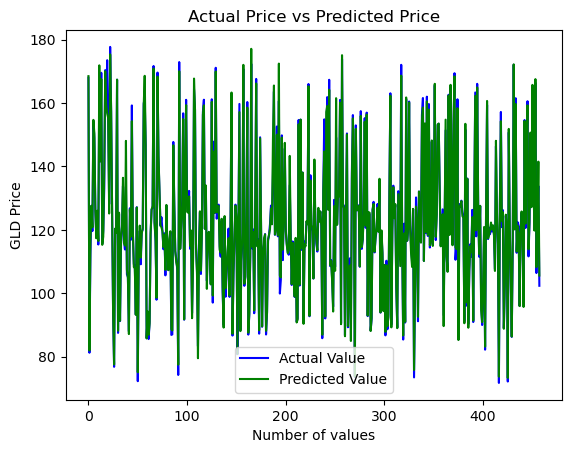

In [55]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

Model Training : Linear Regression

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr = LinearRegression()

lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)
print("Linear Regression Performance")

print("R2 Score:", r2_score(Y_test, lr_pred))
print("MAE:", mean_absolute_error(Y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, lr_pred)))

Linear Regression Performance
R2 Score: 0.8657886565869237
MAE: 5.911486735777761
RMSE: 8.413614015226472


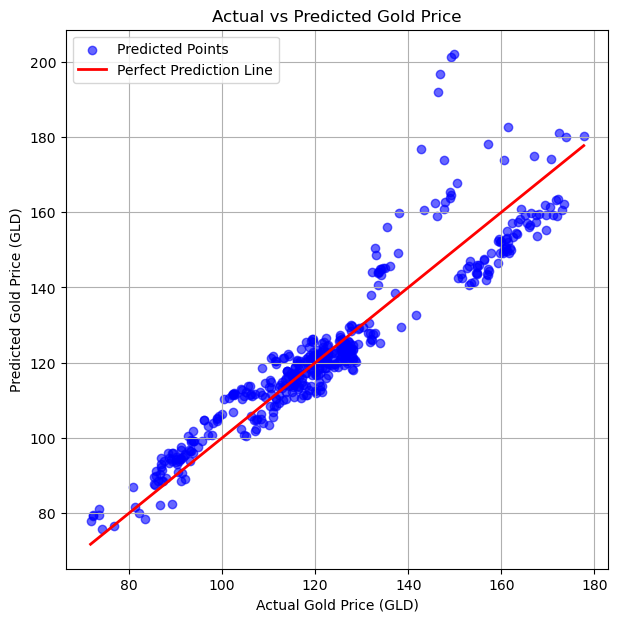

In [86]:
plt.figure(figsize=(7,7))

plt.scatter(Y_test, lr_pred, color="blue", alpha=0.6, label="Predicted Points")

plt.plot([min(Y_test), max(Y_test)],
         [min(Y_test), max(Y_test)],
         color="red",
         linewidth=2,
         label="Perfect Prediction Line")

plt.xlabel("Actual Gold Price (GLD)")
plt.ylabel("Predicted Gold Price (GLD)")
plt.title("Actual vs Predicted Gold Price")

plt.legend()
plt.grid(True)

plt.show()

Model Comparison

In [78]:
print("\nModel Comparison")
print("------------------------------------------------")
print("Model              R2       MAE       RMSE")

print("Linear Regression ",
      r2_score(Y_test, lr_pred),
      mean_absolute_error(Y_test, lr_pred),
      np.sqrt(mean_squared_error(Y_test, lr_pred)))

print("Random Forest     ",
      r2_score(Y_test, rf_pred),
      mean_absolute_error(Y_test, rf_pred),
      np.sqrt(mean_squared_error(Y_test, rf_pred)))


Model Comparison
------------------------------------------------
Model              R2       MAE       RMSE
Linear Regression  0.8657886565869237 5.911486735777761 8.413614015226472
Random Forest      0.9891518715339833 1.3323811498034912 2.3920231716385607


Feature Importance

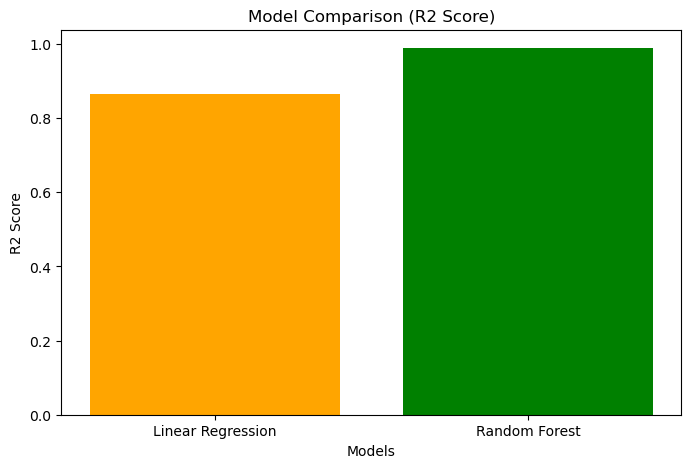

In [101]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [
r2_score(Y_test, lr_pred),
r2_score(Y_test, rf_pred)
]
mae_scores = [5.91, 1.33]
rmse_scores = [8.41, 2.39]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores, color=['orange','green'])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")

plt.show()

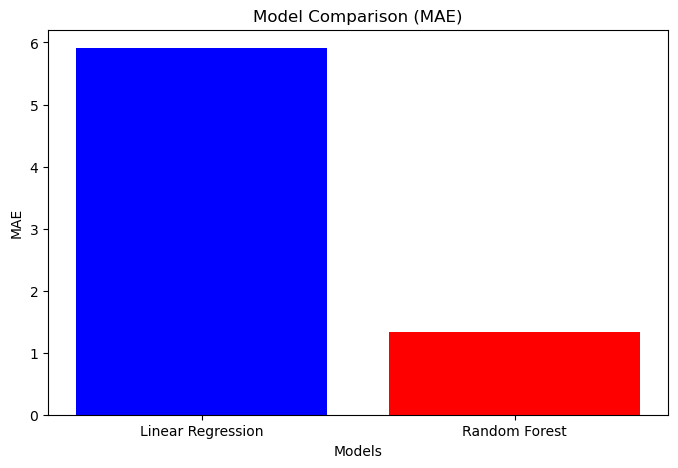

In [103]:
plt.figure(figsize=(8,5))

plt.bar(models, mae_scores, color=['blue','red'])

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison (MAE)")

plt.show()

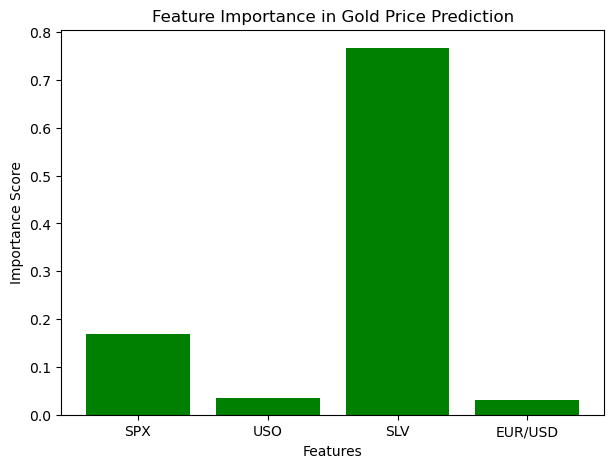

In [105]:
importance = regressor.feature_importances_
features = X.columns

plt.figure(figsize=(7,5))

plt.bar(features, importance, color="green")

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Gold Price Prediction")

plt.show()

Random Forest achieved better performance than Linear Regression with
R² = 0.989, MAE = 1.33, and RMSE = 2.39.

This indicates that tree-based ensemble models can capture complex
non-linear relationships between economic indicators and gold prices.

In [111]:
import pickle

pickle.dump(regressor, open("gold_model.pkl", "wb"))